In [ ]:
from ase.io import read, write
from ase import units
import numpy as np
from imolcryff.crafter.ffxml import merge_xml
from imolcryff.trainer import DistanceTrainer
from imolcryff.calculator.distance import DistanceCalculator
from imolcryff.io.rdkit import atoms2rdkit
from imolcryff.crafter.asemol import aseatoms2pdb, asemol_wrapper, merge_asemols

/Users/srak/apl/iMolCRAFT/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
atoms_snli = read("SNLi.log")

In [3]:
merge_xml(["SN.xml", "Li.xml"], "merged.xml")

'xmlfiles/merged.xml'

In [4]:
calculator = DistanceCalculator(
    atoms_snli,
    1,
    "cn__Li",
    scan_idx=[[5,10]],
    directory="distance_scan",
    qmparams={
             "method": "wb97xd",
             "basis": "6-31g(d)",
             "opt": "modredundant",
             }
)

In [5]:
# calculator.do_qmscan()# 

In [6]:
import glob

g16logs = glob.glob("distance_scan/*.log")

In [ ]:
for i, g16log in enumerate(g16logs):
    atoms = read(g16log)
    distance = atoms.get_distance(5, 10)
    energy = atoms.get_potential_energy()/(units.kJ / units.mol)
    calculator.qm_distancescan[0]["distances_A"].append(distance)
    calculator.qm_distancescan[0]["energy_kjmol"].append(energy)
    calculator.qm_distancescan[0]["atoms"].append(atoms)

distance_scan/cn__Li_dist_0__7.00.log
distance_scan/cn__Li_dist_0__1.75.log
distance_scan/cn__Li_dist_0__1.60.log
distance_scan/cn__Li_dist_0__9.00.log
distance_scan/cn__Li_dist_0__1.70.log
distance_scan/cn__Li_dist_0__5.00.log
distance_scan/cn__Li_dist_0__1.65.log
distance_scan/cn__Li_dist_0__2.50.log
distance_scan/cn__Li_dist_0__3.00.log
distance_scan/cn__Li_dist_0__1.35.log
distance_scan/cn__Li_dist_0__6.00.log
distance_scan/cn__Li_dist_0__1.30.log
distance_scan/cn__Li_dist_0__8.00.log
distance_scan/cn__Li_dist_0__4.00.log
distance_scan/cn__Li_dist_0__1.80.log
distance_scan/cn__Li_dist_0__1.95.log
distance_scan/cn__Li_dist_0__1.40.log
distance_scan/cn__Li_dist_0__1.55.log
distance_scan/cn__Li_dist_0__3.50.log
distance_scan/cn__Li_dist_0__1.45.log
distance_scan/cn__Li_dist_0__2.00.log
distance_scan/cn__Li_dist_0__1.50.log
distance_scan/cn__Li_dist_0__1.85.log
distance_scan/cn__Li_dist_0__1.90.log


In [9]:
# calculator.qm_distancescan[0]でcalculator.qm_distancescan[0]["distances_A"]ベースでソート
# "distances_A"の値で全リストをソート
order = np.argsort(calculator.qm_distancescan[0]["distances_A"])
for key in calculator.qm_distancescan[0]:
	calculator.qm_distancescan[0][key] = [calculator.qm_distancescan[0][key][i] for i in order]

In [ ]:
calculator.do_ffscan("xmlfiles/merged.xml")

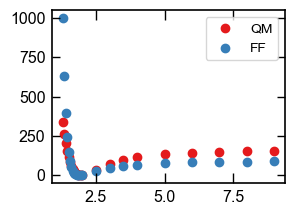

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(calculator.qm_distancescan[0]["distances_A"], np.array(calculator.qm_distancescan[0]["energy_kjmol"])-np.array(calculator.qm_distancescan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_distancescan[0]["distances_A"], np.array(calculator.ff_distancescan[0]["energy_kjmol"])-np.array(calculator.ff_distancescan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

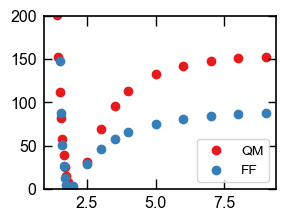

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.ylim(0,200)
plt.scatter(calculator.qm_distancescan[0]["distances_A"], np.array(calculator.qm_distancescan[0]["energy_kjmol"])-np.array(calculator.qm_distancescan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_distancescan[0]["distances_A"], np.array(calculator.ff_distancescan[0]["energy_kjmol"])-np.array(calculator.ff_distancescan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

In [14]:
dtrainer = DistanceTrainer(ffxml_list=["SN.xml", "Li.xml"], 
                           nums_ffxml=[1,1], 
                           pdb="hoge.pdb", 
                           calculator=calculator, 
                           charge_params={"nc": 0.8, "target_lists": [[0,1,2,3,4,5,6,7,8,9]], "target_charges": [0.0]}, 
                           optparam_types=["NonbondedForce/charges", "NonbondedForce/sigma"],
                           sigma_params={"target_list": [4]},
                           lr=0.0001)

optparam_type: NonbondedForce/sigma nonzero


In [15]:
dtrainer.setup()

In [ ]:
dtrainer.fit(steps=2500,relax_steps=100)

epoch 0
loss_tmp 11594.306587531884
epoch 0
loss 11594.306587531884
epoch 1
loss_tmp 11624.537876618422
epoch 2
loss_tmp 11545.66179624957
epoch 3
loss_tmp 11467.23980166774
epoch 4
loss_tmp 11389.280121846356
epoch 5
loss_tmp 11311.789026618595
epoch 6
loss_tmp 11234.77199093085
epoch 7
loss_tmp 11158.233974570132
epoch 8
loss_tmp 11082.179559099857
epoch 9
loss_tmp 11006.612988226167
epoch 10
loss_tmp 10931.538187085967
epoch 11
loss_tmp 10856.958770096371
epoch 12
loss_tmp 10782.878049167153
epoch 13
loss_tmp 10709.299012971207
epoch 14
loss_tmp 10636.224364851289
epoch 15
loss_tmp 10563.656480467682
epoch 16
loss_tmp 10491.597451467373
epoch 17
loss_tmp 10420.049050408668
epoch 18
loss_tmp 10349.012754854357
epoch 19
loss_tmp 10278.489746002397
epoch 20
loss_tmp 10208.480913585194
epoch 21
loss_tmp 10138.9868617004
epoch 22
loss_tmp 10070.007920515676
epoch 23
loss_tmp 10001.544133708336
epoch 24
loss_tmp 9933.59530172392
epoch 25
loss_tmp 9866.160950738114
epoch 26
loss_tmp 9799.2

KeyboardInterrupt: 

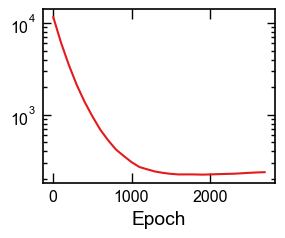

In [31]:
plt.yscale("log")
plt.xlabel("Epoch")
plt.plot(dtrainer.epoch, dtrainer.loss)